# Datacamp Tutorial of DoWhy with Special Focus on Instrumental Variables

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go up one level so 'blocks' is visible

import numpy as np
import pandas as pd
from blocks.simulate import simulate_data
from blocks.draw import draw_duplo_dag
from blocks.sample_dags import start_dag, m_bias_dag
from blocks.add_node import add_node, get_node
from blocks.utils import get_colors

import warnings
warnings.filterwarnings('ignore')

## Duplo method of visualising and generating data

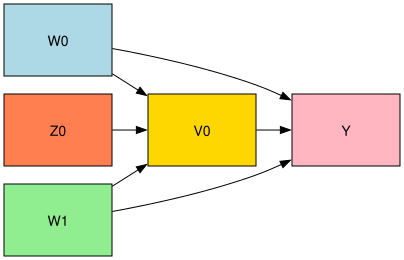

In [4]:
colors = get_colors(5)

nodes = []
add_node(nodes, "W0", colors[0], targets=["V0", "Y"])  # Parent first
add_node(nodes, "W1", colors[1], targets=["V0", "Y"])   # Parent first  
add_node(nodes, "Z0", colors[2], targets=["V0"])        # Parent first
add_node(nodes, "V0", colors[3], targets=["Y"])        # Child second
add_node(nodes, "Y", colors[4], targets=[])              # Child last

draw_duplo_dag(nodes)

In [5]:
data = simulate_data(nodes, n=1000, seed=42)
print(data.head())

         W0        W1        Z0        V0         Y
0  0.496714  1.399355 -0.675178 -0.686916  0.345660
1 -0.138264  0.924634 -0.144519 -0.218534  0.536632
2  0.647689  0.059630 -0.792420 -0.498707  0.226629
3  1.523030 -0.646937 -0.307962  2.455819  3.804543
4 -0.234153  0.698223 -1.893615 -0.872992 -1.775780


# Following a tutorial using the DoWhy Library
- DoWhy gives you more flexbility in sampling, but you can't do it directly from your DAG model
- https://www.datacamp.com/tutorial/intro-to-causal-ai-using-the-dowhy-library-in-python

### DoWhy's linear_dataset() function does two things simultaneously:
1. Creates the data based on the parameters you specify
2. Creates the corresponding causal graph and stores it in data['gml_graph']

In [6]:
from dowhy import CausalModel
import dowhy.datasets

# Set seed to enable exact replication
np.random.seed(1)

# Simulate sample data
data = dowhy.datasets.linear_dataset(
    beta=1,
    num_common_causes=2, # These are the confounders
    num_discrete_common_causes=1, # Of which one of them is binary
    num_instruments=1, # This is the Instrument Variable as an additional cause
    num_samples=10000,
    treatment_is_binary=True)

df = data['df']

In [7]:
df.head()

,Z0,W0,W1,v0,y
0,0.0,-0.694128,0,True,0.510989
1,1.0,0.699452,0,True,1.495845
2,0.0,1.578856,0,False,1.112997
3,0.0,0.153083,1,True,1.849269
4,0.0,1.296152,0,True,1.931800


### Now use the graph that DoWhy automatically created during data generation to create the Causal Model

In [8]:
# Create a causal model from the data and given graph.
model=CausalModel(
        data = df,
        treatment=data['treatment_name'],
        outcome=data['outcome_name'],
        graph=data['gml_graph']
        )

In [9]:
# Run a linear regression of column y on v0 in df
import statsmodels.api as sm

X = df['v0'].astype(float)
y = df['y'].astype(float)

X = sm.add_constant(X)

ols = sm.OLS(y, X).fit()

# Display a more parsimonious results summary
print(ols.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7966      0.017     47.194      0.000       0.764       0.830
v0             1.2947      0.022     59.804      0.000       1.252       1.337


## identify_effect(): 
- Checks if the causal effect can be identified given your graph and data.
- It applies causal identification rules (backdoor criterion, front-door, etc.) and rturns the target estimands.

In [10]:
identified_estimand = model.identify_effect()

In [11]:
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                      -1⎤
 ⎢  d      ⎛  d        ⎞  ⎥
E⎢─────(y)⋅⎜─────([v₀])⎟  ⎥
 ⎣d[Z₀]    ⎝d[Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0})
Estimand assumption 2, Exclusion: If we remove {Z0}→{v0}, then ¬({Z0}→y)

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)



## estimate_effect(): 
- Computes the causal effect using the method you specify (regression, propensity score weighting, matching, etc.)

In [12]:
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_weighting")

In [13]:
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
  d              
─────(E[y|W0,W1])
d[v₀]            
Estimand assumption 1, Unconfoundedness: If U→{v0} and U→y then P(y|v0,W0,W1,U) = P(y|v0,W0,W1)

## Realized estimand
b: y~v0+W0+W1
Target units: ate

## Estimate
Mean value: 1.000777480613904



## Now let's performa a sensitivity analysis 
It tests how robust your causal estimate is to violations of the "no unobserved confounders" assumption.
What This Test Does
The add_unobserved_common_cause refutation simulates what would happen if there was a hidden confounder you didn't account for. It:

Adds a synthetic unobserved variable that affects both treatment and outcome
Re-estimates the causal effect with this hidden confounder
Compares the new estimate to your original estimate

Why This Matters
Your causal inference assumes you've controlled for all confounders. But what if you missed one? This test shows how sensitive your results are to that assumption.
What the Results Tell You
Small change in estimate: Your result is robust to unobserved confounding
Large change in estimate: Your result is sensitive - hidden confounders could dramatically change your conclusion

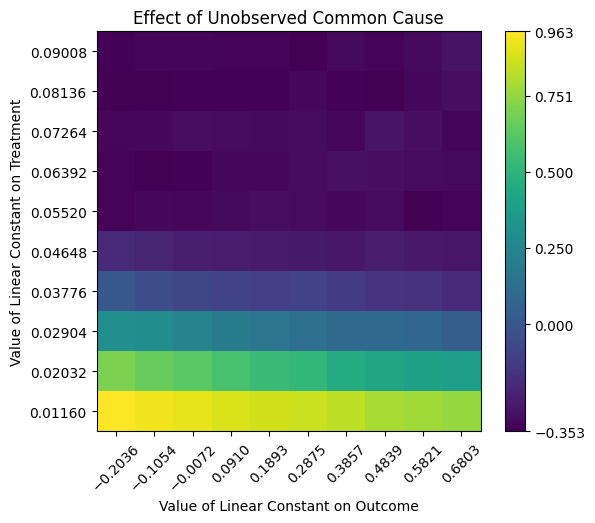

In [14]:
# Check sensitivity of obtained estimate to unobserved confounders
refute_results = model.refute_estimate(identified_estimand, estimate, method_name="add_unobserved_common_cause")

## What Instrumental Variables Are
An instrumental variable is a variable that:

Affects the treatment (subway closure → more work from home)
Only affects the outcome through the treatment (closure doesn't directly affect productivity, only through WFH)
Is unrelated to confounders (closure is random, not related to employee characteristics)

In [15]:
iv_estimate = model.estimate_effect(identified_estimand,
                                    method_name="iv.instrumental_variable")

In [16]:
print(iv_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: iv
Estimand expression:
 ⎡                      -1⎤
 ⎢  d      ⎛  d        ⎞  ⎥
E⎢─────(y)⋅⎜─────([v₀])⎟  ⎥
 ⎣d[Z₀]    ⎝d[Z₀]      ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0})
Estimand assumption 2, Exclusion: If we remove {Z0}→{v0}, then ¬({Z0}→y)

## Realized estimand
Realized estimand: Wald Estimator
Realized estimand type: EstimandType.NONPARAMETRIC_ATE
Estimand expression:
 ⎡ d    ⎤ 
E⎢───(y)⎥ 
 ⎣dZ₀   ⎦ 
──────────
 ⎡ d     ⎤
E⎢───(v₀)⎥
 ⎣dZ₀    ⎦
Estimand assumption 1, As-if-random: If U→→y then ¬(U →→{Z0})
Estimand assumption 2, Exclusion: If we remove {Z0}→{v0}, then ¬({Z0}→y)
Estimand assumption 3, treatment_effect_homogeneity: Each unit's treatment ['v0'] is affected in the same way by common causes of ['v0'] and ['y']
Estimand assumption 4, outcome_effect_homogeneity: Each unit's outcome ['y'] is affected in the same way by com

## Why IV is Valuable
- Backdoor adjustment: Assumes you've controlled for all confounders
- IV approach: Doesn't require knowing all confounders - uses "random" variation
- The trade-off: IV estimates are often less precise but more robust to hidden confounding.
- This shows DoWhy's power - it can automatically recognize different causal identification strategies (backdoor, IV, front-door) and apply the appropriate method based on your graph structure. Your Z0 variable was serving as an instrument all along.

How IV Works with Your Graph
Z0 as instrument:

Z0 → V0 (affects the treatment)
Z0 has no direct path to Y (only through V0)
Z0 is unrelated to the confounders W0 and W1

The IV strategy:

Uses only the variation in V0 that comes from Z0
Ignores the confounded variation from W0 and W1
Estimates V0 → Y effect using this "clean" variation

What IV Accomplishes
Instead of trying to control for W0 and W1 (which you might not even observe in real data), IV sidesteps them entirely. It asks: "When Z0 randomly pushes V0 higher, what happens to Y?"

# IV in action: The Classic Education-Income Problem
Research question: Does education cause higher income?
The confounding problem:

Smart people get more education AND earn more money
Family wealth affects both education AND income
Motivation affects both education AND income

So simply comparing college graduates to high school graduates gives you a biased estimate.
The Instrumental Variable Solution
Instrument: Distance to nearest college
Why this works:

Affects treatment: People living farther from college are less likely to attend (travel costs, housing costs)
Random with respect to ability: Where your parents happened to live when you were born is unrelated to your intelligence or motivation
Only affects income through education: Living near a college doesn't directly make you more productive at work

The IV Logic
Instead of comparing all college grads vs all high school grads (confounded), IV compares:

People who went to college ONLY because they lived near one
vs People who didn't go ONLY because they lived far away

This gives you the causal effect for people on the margin - those whose education decision was influenced by the random factor (distance).
Why This Sidesteps Confounders
You don't need to measure or control for intelligence, family wealth, or motivation. The instrument creates variation in education that's unrelated to these confounders.

### The key insight: IV uses a "natural experiment" where geography randomly assigns some people higher probability of college attendance, letting you estimate the causal effect without knowing all the confounders.

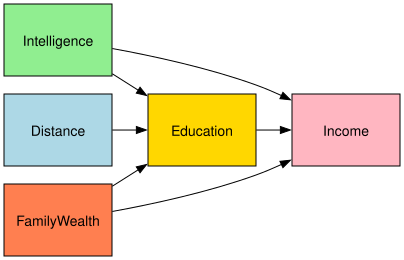

In [17]:
from blocks.utils import get_colors

colors = get_colors(5)  # Get 5 distinct colors

education_iv_dag = []
add_node(education_iv_dag, "Distance", colors[0], targets=["Education"]) # IV
add_node(education_iv_dag, "Intelligence", colors[1], targets=["Education", "Income"]) # Confounder 1
add_node(education_iv_dag, "FamilyWealth", colors[2], targets=["Education", "Income"]) # Confounder 2
add_node(education_iv_dag, "Education", colors[3], targets=["Income"]) # Treatment
add_node(education_iv_dag, "Income", colors[4], targets=[]) # Ouctome

draw_duplo_dag(education_iv_dag)